In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from imblearn.over_sampling import SMOTENC
from sklearn.preprocessing import LabelEncoder 
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (confusion_matrix, classification_report, matthews_corrcoef, roc_curve, roc_auc_score,
							accuracy_score, precision_score, recall_score, f1_score)

In [3]:
import random
# setting seed so the results are consistently reproducible
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [4]:
train=pd.read_csv("data/preprocessedTrain.csv")
test=pd.read_csv("data/preprocessedTest.csv")

In [5]:
# To fill nulls
train['f_Header_b_payload_Ratio'] = train['f_Header_b_payload_Ratio'].replace(np.nan, train['f_Header_b_payload_Ratio'].max() + 1) 
train['b_Header_f_payload_Ratio'] = train['b_Header_f_payload_Ratio'].replace(np.nan, train['b_Header_f_payload_Ratio'].max() + 1) 
test['f_Header_b_payload_Ratio'] = test['f_Header_b_payload_Ratio'].replace(np.nan, test['f_Header_b_payload_Ratio'].max() + 1) 
test['b_Header_f_payload_Ratio'] = test['b_Header_f_payload_Ratio'].replace(np.nan, test['b_Header_f_payload_Ratio'].max() + 1) 

In [6]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Train class counts:\n", train["Attack_type"].value_counts())
print("Test class counts:\n", test["Attack_type"].value_counts())

Train shape: (98493, 84)
Test shape: (24624, 84)
Train class counts:
 Attack_type
DOS_SYN_Hping                 75727
Thing_Speak                    6486
ARP_poisioning                 6200
MQTT_Publish                   3317
NMAP_UDP_SCAN                  2072
NMAP_XMAS_TREE_SCAN            1608
NMAP_OS_DETECTION              1600
NMAP_TCP_scan                   802
DDOS_Slowloris                  427
Wipro_bulb                      202
Metasploit_Brute_Force_SSH       30
NMAP_FIN_SCAN                    22
Name: count, dtype: int64
Test class counts:
 Attack_type
DOS_SYN_Hping                 18932
Thing_Speak                    1622
ARP_poisioning                 1550
MQTT_Publish                    829
NMAP_UDP_SCAN                   518
NMAP_XMAS_TREE_SCAN             402
NMAP_OS_DETECTION               400
NMAP_TCP_scan                   200
DDOS_Slowloris                  107
Wipro_bulb                       51
Metasploit_Brute_Force_SSH        7
NMAP_FIN_SCAN                   

In [7]:
def to_binary_label(y):
    # 0 = benign, 1 = malicious
    benign = ['MQTT_Publish', 'Thing_Speak', 'Wipro_bulb']
    return [0 if val in benign else 1 for val in y]

y_train = to_binary_label(train["Attack_type"])
y_test = to_binary_label(test["Attack_type"])

X_train = train.drop("Attack_type", axis=1)
X_test = test.drop("Attack_type", axis=1).values

## Train-Val Split

In [8]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)
X_val = X_val.values

In [9]:
values, counts = np.unique(y_train, return_counts=True)
print(values)  
print(counts) 

[0 1]
[ 8004 70790]


In [10]:
# # put the ports back to one col.
# mapping = {
#     (1,0): 'icmp',
#     (0,1): 'tcp',
#     (0,0): 'udp'
# }

# X_train['proto'] = list(zip(X_train.proto_icmp, X_train.proto_tcp))
# X_train['proto'] = X_train['proto'].map(mapping)
# X_train = X_train.drop(['proto_icmp','proto_tcp'],axis=1)

# smote = SMOTENC(random_state=42,categorical_features=[2,81],sampling_strategy={0: np.rint(4960*1.2,).astype(int),
#                                                                             1: np.rint(342*2).astype(int),
#                                                                             })
# X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
# X_train_res = pd.get_dummies(X_train_res)
# X_train_res = X_train_res.drop(['proto_udp'],axis=1)

# # need to reorder back to original ordering
# cols = list(X_train_res.columns)
# col1 = cols.pop(81)  #icmp
# col2 = cols.pop(81)  #tcp
# cols.insert(77, col2)
# cols.insert(77, col1)
# X_train_res = X_train_res[cols]

# X_train_res=X_train_res.values
# X_train_res = X_train_res.astype(np.float32)
X_train_res = X_train.values
y_train_res = y_train

In [11]:
X_train_tensor = torch.tensor(X_train_res, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_res, dtype=torch.float32).view(-1, 1)

# TEST
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

# Validation
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32) 

In [12]:
X_train_tensor = X_train_tensor.unsqueeze(1)
X_test_tensor = X_test_tensor.unsqueeze(1)
X_val_tensor = X_val_tensor.unsqueeze(1)


train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)


train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)
val_loader = DataLoader(val_dataset, batch_size=64)

In [13]:
class BinaryCNN(nn.Module):
    def __init__(self, input_length=83, dropout_rate=0.3):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(16)

        self.conv2 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(32)

        self.pool = nn.MaxPool1d(2)
        self.dropout = nn.Dropout1d(dropout_rate)

        self.flatten_dim = 32 * (input_length // 2)

        self.fc1 = nn.Linear(self.flatten_dim, 64)
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(self.dropout(x)))
        x = self.fc2(x)

        return x
    
# Check if gpu is available and set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [14]:
model = BinaryCNN()  
model = model.to(device) 

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

In [15]:
num_epochs = 25

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    total_loss = 0.0
    print("start epcoh")

    for batch, (X_batch, y_batch) in enumerate(train_loader):
        # WHY?
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        X_batch = X_batch.float()  
        y_batch = y_batch.float()

        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss+=loss.item()
        running_loss += loss.item()

        if (batch+1) % 500 == 0:
            print(f"[{epoch+1}, {batch+1}] loss: {running_loss/500:.4f}")
            running_loss = 0.0

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss / len(train_loader):.4f}")

start epcoh
[1, 500] loss: 0.2692
[1, 1000] loss: 0.2232
Epoch [1/25], Loss: 0.2378
start epcoh
[2, 500] loss: 0.1805
[2, 1000] loss: 0.1620
Epoch [2/25], Loss: 0.1663
start epcoh
[3, 500] loss: 0.1360
[3, 1000] loss: 0.1230
Epoch [3/25], Loss: 0.1275
start epcoh
[4, 500] loss: 0.1146
[4, 1000] loss: 0.1175
Epoch [4/25], Loss: 0.1157
start epcoh
[5, 500] loss: 0.1132
[5, 1000] loss: 0.1113
Epoch [5/25], Loss: 0.1129
start epcoh
[6, 500] loss: 0.1102
[6, 1000] loss: 0.1087
Epoch [6/25], Loss: 0.1109
start epcoh
[7, 500] loss: 0.1097
[7, 1000] loss: 0.1116
Epoch [7/25], Loss: 0.1107
start epcoh
[8, 500] loss: 0.1115
[8, 1000] loss: 0.1078
Epoch [8/25], Loss: 0.1102
start epcoh
[9, 500] loss: 0.1057
[9, 1000] loss: 0.1076
Epoch [9/25], Loss: 0.1068
start epcoh
[10, 500] loss: 0.1044
[10, 1000] loss: 0.1066
Epoch [10/25], Loss: 0.1058
start epcoh
[11, 500] loss: 0.1076
[11, 1000] loss: 0.1032
Epoch [11/25], Loss: 0.1060
start epcoh
[12, 500] loss: 0.1064
[12, 1000] loss: 0.1064
Epoch [12/2

In [17]:
model.eval()
all_preds = []
all_labels = []
all_probs = []  

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        probs = torch.sigmoid(outputs)               
        preds = (probs > 0.5).int()                 

        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
print(cm)

report = classification_report(all_labels, all_preds, target_names=["Benign", "Malicious"], output_dict=True)
print(classification_report(all_labels, all_preds, target_names=["Benign", "Malicious"]))


[[ 2448    54]
 [   20 22102]]
              precision    recall  f1-score   support

      Benign       0.99      0.98      0.99      2502
   Malicious       1.00      1.00      1.00     22122

    accuracy                           1.00     24624
   macro avg       0.99      0.99      0.99     24624
weighted avg       1.00      1.00      1.00     24624



ROC-AUC: 0.996769413869501


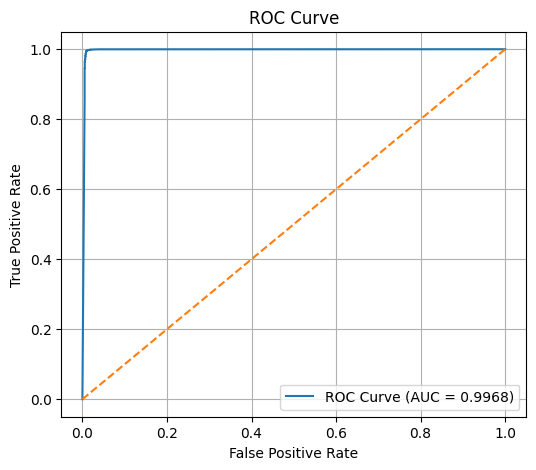

Success


In [18]:

roc_auc = roc_auc_score(all_labels, all_probs)
print("ROC-AUC:", roc_auc)

fpr, tpr, thresholds = roc_curve(all_labels, all_probs)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")         # diagonal baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)

plt.savefig("classification_reports/roc_curve_cnn_binary.png", dpi=300)
plt.show()
plt.close()

report["ROC_AUC"] = {"Score": roc_auc}
report_df = pd.DataFrame(report).transpose()
report_df.to_csv("classification_reports/evaluation_metrics_cnn_binary_roc.csv", index=True)
print("Success")


In [19]:
acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds, average='macro')
rec = recall_score(all_labels, all_preds, average='macro')
f1 = f1_score(all_labels, all_preds, average='macro')
precw = precision_score(all_labels, all_preds)
recw = recall_score(all_labels, all_preds)
f1w = f1_score(all_labels, all_preds)
mcc = matthews_corrcoef(all_labels, all_preds)


print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=["Benign", "Malicious"]))
print(f"\nOverall Metrics:")
print(f"Accuracy: {acc:.4f}")
print(f"Macro Precision: {prec:.4f}")
print(f"Macro Recall: {rec:.4f}")
print(f"Macro F1 Score: {f1:.4f}")
print(f"Precision: {precw:.4f}")
print(f"Recall: {recw:.4f}")
print(f"F1 Score: {f1w:.4f}")
print(f"MCC Score: {mcc:.4f}")


Classification Report:
              precision    recall  f1-score   support

      Benign       0.99      0.98      0.99      2502
   Malicious       1.00      1.00      1.00     22122

    accuracy                           1.00     24624
   macro avg       0.99      0.99      0.99     24624
weighted avg       1.00      1.00      1.00     24624


Overall Metrics:
Accuracy: 0.9970
Macro Precision: 0.9947
Macro Recall: 0.9888
Macro F1 Score: 0.9917
Precision: 0.9976
Recall: 0.9991
F1 Score: 0.9983
MCC Score: 0.9835


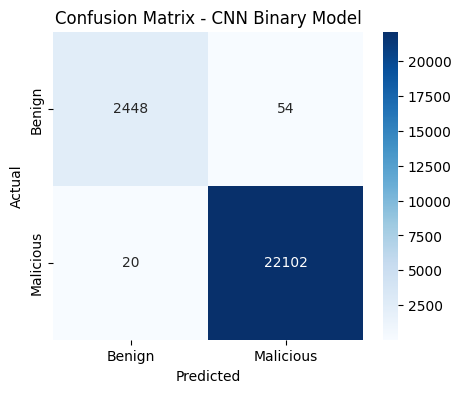

In [20]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Benign", "Malicious"], yticklabels=["Benign", "Malicious"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - CNN Binary Model")
plt.savefig("confusionmatrices/1dcnn_binary.png", dpi=600, bbox_inches='tight')
plt.show()

In [21]:
torch.save(model.state_dict(), "models/1dcnn_binary.pth")
print("Model saved to 1dcnn_binary.pth")

Model saved to 1dcnn_binary.pth
